In [31]:
from HR import HR
from Metric import metric_factory
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [46]:
def transform_distribution(team_nominal_roll):
    transformed_local = pd.DataFrame(index=team_nominal_roll.index)
    num_cols = team_nominal_roll.select_dtypes(include=np.number).columns.tolist()
    eligible_cols_local = []
    for col in num_cols:
        selected_column = team_nominal_roll[team_nominal_roll[col] != 0][col]
        selected_column.dropna(inplace=True)
        remaining_team = pd.DataFrame(index=selected_column.index)
        try:
            xt, _ = stats.boxcox(selected_column)
            remaining_team[col] = xt
            transformed_local = transformed_local.join(remaining_team)
            eligible_cols_local.append(col)
        except: # will not work when value is negative
            continue
    return transformed_local, eligible_cols_local

def detect_outliers(team_nominal_roll, eligible_cols):
    outlier = pd.DataFrame(index=team_nominal_roll.index)
    for col in eligible_cols:
        outlier[col] = team_nominal_roll[col]
        outlier.dropna(inplace=True)
        outlier[col] = stats.zscore(outlier[col])
        outlier[col] = np.select(
            [
            outlier[col] > 1.96,
            outlier[col] > 1.5,
            outlier[col] > 1,
            outlier[col] < -1.96,
            outlier[col] < -1.5,
            outlier[col] < -1
            ],
            [
                '⬆️⬆️⬆️',
                '⬆️⬆️',
                '⬆️',
                '⬇️⬇️⬇️',
                '⬇️⬇️',
                '⬇️'
            ],
        default=''
        )
    return outlier

def metric_to_df(team_nominal_roll, metric):
    return team_nominal_roll.merge(metric, how='left', left_on=['Team'], right_on=['Team'])


In [47]:
hr_obj = HR("Job_Title")

Finished loading Job_Title HR data


In [48]:
team_nominal_roll = hr_obj.get_number_of_people_team()[['Team']]
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('overtime', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('satisfaction', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('sickness', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('training', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('workload', hr_obj).get_df())
team_nominal_roll.set_index('Team', inplace=True)

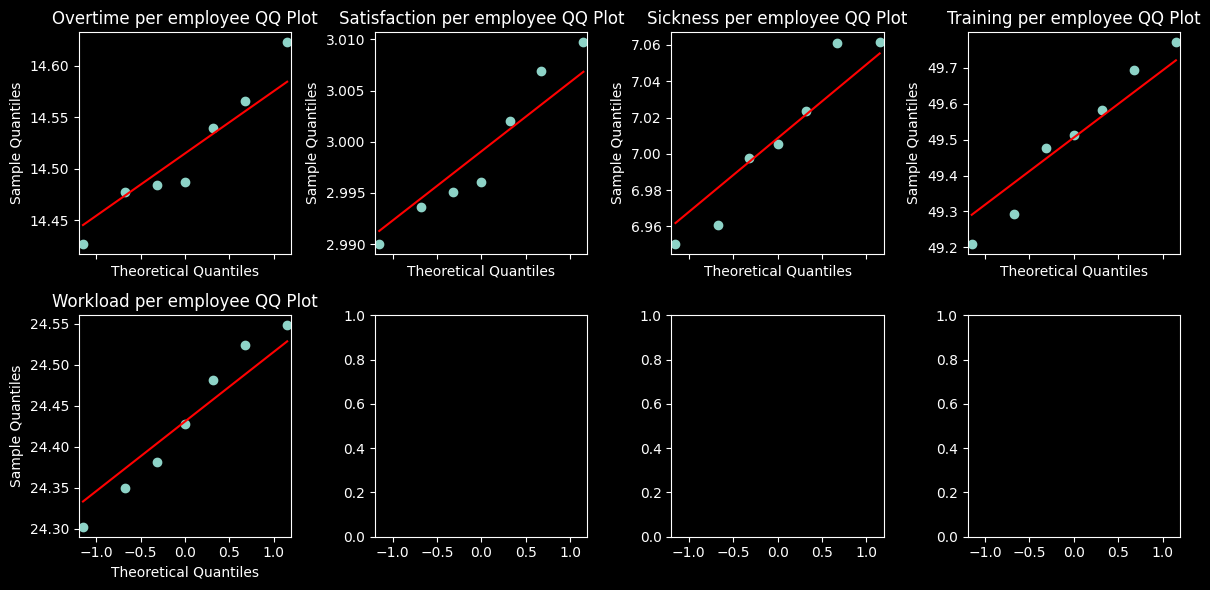

In [49]:
fig, axes = plt.subplots(ncols=4, nrows=2, sharex=True, figsize=(4*3, 2*3))
for k, ax in zip(team_nominal_roll.columns, np.ravel(axes)):
    sm.qqplot(team_nominal_roll[k], line='s', ax=ax)
    ax.set_title(f'{k} QQ Plot')
plt.tight_layout()
plt.show()


In [50]:
_, eligble_col = transform_distribution(team_nominal_roll) # will not be using box-cox because all metrics follow the normal distribution quite well.
# team_nominal_roll, eligble_col = transform_distribution(team_nominal_roll) # will not be using box-cox because all metrics follow the normal distribution quite well.

team_nominal_roll = detect_outliers(team_nominal_roll, eligble_col)

In [51]:
team_nominal_roll

,Overtime per employee,Satisfaction per employee,Sickness per employee,Training per employee,Workload per employee
Team,,,,,
Analyst,,,⬆️,,
Consultant,⬆️⬆️,⬆️,⬆️,⬇️,
Developer,,,⬇️,⬆️,
Engineer,⬇️,,,,⬆️
Manager,,,,⬇️⬇️,⬇️⬇️
Specialist,,⬆️⬆️,,⬆️,
Technician,,⬇️,⬇️,,⬆️


In [52]:
hr_obj = HR("Department")

Finished loading Department HR data


In [53]:
team_nominal_roll = hr_obj.get_number_of_people_team()[['Team']]
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('overtime', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('satisfaction', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('sickness', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('training', hr_obj).get_df())
team_nominal_roll = metric_to_df(team_nominal_roll, metric_factory('workload', hr_obj).get_df())
team_nominal_roll.set_index('Team', inplace=True)

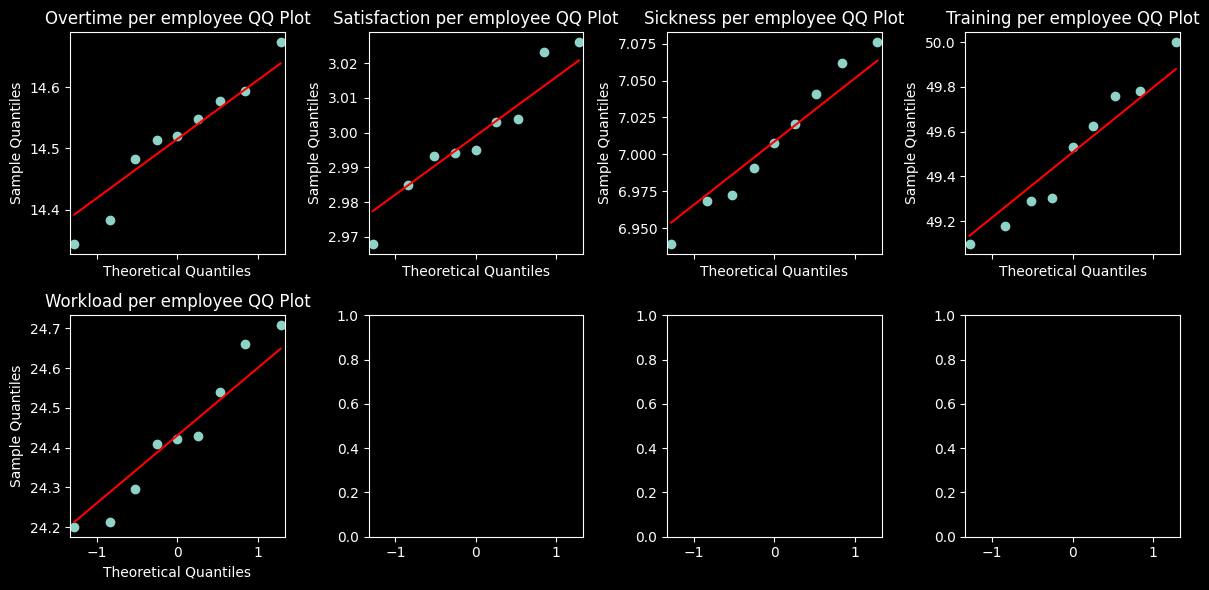

In [54]:
fig, axes = plt.subplots(ncols=4, nrows=2, sharex=True, figsize=(4*3, 2*3))
for k, ax in zip(team_nominal_roll.columns, np.ravel(axes)):
    sm.qqplot(team_nominal_roll[k], line='s', ax=ax)
    ax.set_title(f'{k} QQ Plot')
plt.tight_layout()
plt.show()

In [55]:
_, eligble_col = transform_distribution(team_nominal_roll) # will not be using box-cox because all metrics follow the normal distribution quite well.
team_nominal_roll = detect_outliers(team_nominal_roll, eligble_col)

In [56]:
team_nominal_roll

,Overtime per employee,Satisfaction per employee,Sickness per employee,Training per employee,Workload per employee
Team,,,,,
Customer Support,⬇️,⬇️⬇️,⬆️,,
Engineering,,,,⬆️⬆️,
Finance,⬇️⬇️,,⬆️⬆️,,
HR,,,,,⬇️
IT,⬆️⬆️,⬆️,,⬇️,
Legal,,,⬇️⬇️,,⬇️
Marketing,,,,,⬆️
Operations,,⬆️⬆️,,⬇️,
Sales,,,,,⬆️⬆️
